In [2]:
# For loading datasets
import medmnist
from medmnist import BreastMNIST, PneumoniaMNIST
# For computation
import numpy as np
# For loading data
import torch
import torch.utils.data as data
import torchvision.transforms as transforms

# For computing with-class scatter matrix & between-class scatter matrix
from calculate_L import calculate_L

# For LSSVM 
# See https://github.com/RomuloDrumond/LSSVM
from lssvm import LSSVC

In [3]:
# device
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Load data and visualize

In [4]:
# preprocessing
data_transform = transforms.Compose([
    transforms.ToTensor(),
    #transforms.Normalize(mean=[.5], std=[.5])
])

In [5]:
# e.g. BreastMNIST 
train_dataset = BreastMNIST(root='./data/', split='train', download=True, transform=data_transform)
test_dataset = BreastMNIST(root='./data/', split='test', download=True, transform=data_transform)

Using downloaded and verified file: ./data/breastmnist.npz
Using downloaded and verified file: ./data/breastmnist.npz


In [7]:
# encapsulate data into dataloader form
train_loader = data.DataLoader(dataset=train_dataset, batch_size=len(train_dataset), shuffle=True)
test_loader = data.DataLoader(dataset=test_dataset, batch_size=len(test_dataset), shuffle=False)

In [8]:
print(train_dataset)
print("===================")
print(test_dataset)

Dataset BreastMNIST of size 28 (breastmnist)
    Number of datapoints: 546
    Root location: ./data/
    Split: train
    Task: binary-class
    Number of channels: 1
    Meaning of labels: {'0': 'malignant', '1': 'normal, benign'}
    Number of samples: {'train': 546, 'val': 78, 'test': 156}
    Description: The BreastMNIST is based on a dataset of 780 breast ultrasound images. It is categorized into 3 classes: normal, benign, and malignant. As we use low-resolution images, we simplify the task into binary classification by combining normal and benign as positive and classifying them against malignant as negative. We split the source dataset with a ratio of 7:1:2 into training, validation and test set. The source images of 1×500×500 are resized into 1×28×28.
    License: CC BY 4.0
Dataset BreastMNIST of size 28 (breastmnist)
    Number of datapoints: 156
    Root location: ./data/
    Split: test
    Task: binary-class
    Number of channels: 1
    Meaning of labels: {'0': 'malignant

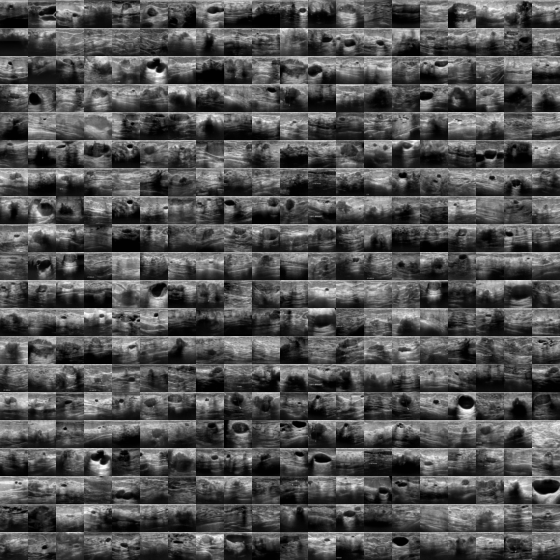

In [13]:
# visualization
train_dataset.montage(length=20)